In [1]:
!pip install pyarrow

In [2]:
!pip install -q scikit-learn==1.6.0

In [3]:
import sklearn
print(sklearn.__version__)

1.6.0


In [4]:
import pandas as pd

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

In [29]:
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge

from sklearn.metrics import root_mean_squared_error

In [60]:
import pickle

In [7]:
df = pd.read_parquet('https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2025-01.parquet')

In [8]:
df.head()

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,cbd_congestion_fee
0,2,2025-01-01 00:03:01,2025-01-01 00:17:12,N,1.0,75,235,1.0,5.93,24.70,...,0.5,6.80,0.00,NaN,1.0,34.00,1.0,1.0,0.00,0.0
1,2,2025-01-01 00:19:59,2025-01-01 00:25:52,N,1.0,166,75,1.0,1.32,8.60,...,0.5,0.00,0.00,NaN,1.0,11.10,2.0,1.0,0.00,0.0
2,2,2025-01-01 00:05:29,2025-01-01 00:07:21,N,5.0,171,73,1.0,0.41,25.55,...,0.0,0.00,0.00,NaN,1.0,26.55,2.0,2.0,0.00,0.0
3,2,2025-01-01 00:52:24,2025-01-01 01:07:52,N,1.0,74,223,1.0,4.12,21.20,...,0.5,6.13,6.94,NaN,1.0,36.77,1.0,1.0,0.00,0.0
4,2,2025-01-01 00:25:05,2025-01-01 01:01:10,N,1.0,66,158,1.0,4.71,33.80,...,0.5,7.81,0.00,NaN,1.0,46.86,1.0,1.0,2.75,0.0


Duration = Dropoff time - Pickup time

In [9]:
df.lpep_dropoff_datetime - df.lpep_pickup_datetime

0       0 days 00:14:11
1       0 days 00:05:53
2       0 days 00:01:52
3       0 days 00:15:28
4       0 days 00:36:05
              ...      
48321   0 days 00:29:00
48322   0 days 00:08:00
48323   0 days 00:21:00
48324   0 days 00:03:00
48325   0 days 00:07:00
Length: 48326, dtype: timedelta64[ns]

In [10]:
df ['duration_mins'] = df.lpep_dropoff_datetime - df.lpep_pickup_datetime

Converting duration to minutes

In [11]:
td = df.duration_mins[0]

In [12]:
td.total_seconds() / 60

14.183333333333334

In [13]:
df.duration_mins = df.duration_mins.apply(lambda td: td.total_seconds() / 60)

In [14]:
df.duration_mins.describe()

count    48326.000000
mean        19.955195
std         93.924039
min          0.000000
25%          7.200000
50%         11.250000
75%         16.983333
max       1439.650000
Name: duration_mins, dtype: float64

In [15]:
df.duration_mins.describe(percentiles = [0.95, 0.98, 0.99])

count    48326.000000
mean        19.955195
std         93.924039
min          0.000000
50%         11.250000
95%         32.366667
98%         44.983333
99%         61.991667
max       1439.650000
Name: duration_mins, dtype: float64

In [16]:
((df.duration_mins >= 1) & (df.duration_mins <= 60)).mean()

0.9582212473616687

In [17]:
#df = ((df.duration_mins >= 1) & (df.duration_mins <= 60))
df = df[(df.duration_mins >= 1) & (df.duration_mins <= 60)]


Feature Selection:

In [18]:
categorical = ['PULocationID', 'DOLocationID']
numerical = ['trip_distance']

In [19]:
df[categorical]

,PULocationID,DOLocationID
0,75,235
1,166,75
2,171,73
3,74,223
4,66,158
...,...,...
48321,179,132
48322,166,75
48323,41,42
48324,75,43


In [20]:
train_dicts = df[categorical + numerical].to_dict(orient='records')

dv = DictVectorizer()
X_train = dv.fit_transform(train_dicts)

target = 'duration_mins'
y_train = df[target].values

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_train)

mean_squared_error(y_train, y_pred)

72.73551980511229

/home/codespace/anaconda3/lib/python3.9/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
/home/codespace/anaconda3/lib/python3.9/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


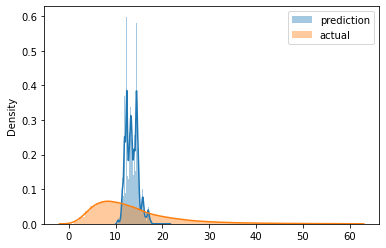

In [21]:
sns.distplot(y_pred, label='prediction')
sns.distplot(y_train, label='actual')

plt.legend()

In [22]:
def read_dataframe(filename):
    if filename.endswith('.csv'):
        df = pd.read_csv(filename)

        df.lpep_dropoff_datetime = pd.to_datetime(df.lpep_dropoff_datetime)
        df.lpep_pickup_datetime = pd.to_datetime(df.lpep_pickup_datetime)
    elif filename.endswith('.parquet'):
        df = pd.read_parquet(filename)

    df['duration'] = df.lpep_dropoff_datetime - df.lpep_pickup_datetime
    df.duration = df.duration.apply(lambda td: td.total_seconds() / 60)

    df = df[(df.duration >= 1) & (df.duration <= 60)]

    categorical = ['PULocationID', 'DOLocationID']
    df[categorical] = df[categorical].astype(str)
    
    return df

Training and Validation:

In [23]:
df_train = read_dataframe('https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2025-01.parquet')
df_val = read_dataframe('https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2025-02.parquet')

In [24]:
len(df_train), len(df_val)

(46307, 44218)

In [25]:
df_train['PU_DO'] = df_train['PULocationID'] + '_' + df_train['DOLocationID']
df_val['PU_DO'] = df_val['PULocationID'] + '_' + df_val['DOLocationID']

In [50]:
df_train['trip_type'].dtype

dtype('float64')

In [51]:
df_train['trip_type'] = df_train['trip_type'].astype(str)

In [52]:
categorical = ['PU_DO', 'trip_type'] #'PULocationID', 'DOLocationID']
numerical = ['trip_distance']

dv = DictVectorizer()

train_dicts = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dicts)

val_dicts = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dicts)

In [53]:
target = 'duration'
y_train = df_train[target].values
y_val = df_val[target].values

Linear Regression:

In [54]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_val)

root_mean_squared_error(y_val, y_pred)

6.154501545262343

Lasso:

In [59]:
ls = Lasso(0.1)
ls.fit(X_train, y_train)

y_pred = ls.predict(X_val)

root_mean_squared_error(y_val, y_pred)

9.03424026620296

In [64]:
#Lasso regressor gives the best rmse value
import os
os.makedirs('models', exist_ok=True)

with open('models/lin_reg.bin', 'wb') as f_out:
    pickle.dump((dv, ls), f_out)

Ridge:

In [58]:
r = Ridge(0.1)
r.fit(X_train, y_train)

y_pred = r.predict(X_val)

root_mean_squared_error(y_val, y_pred)

6.142134216252079